# Schema Validation Exercise 3: analysis and adjudication

This notebook mirrors the Validation 2 analysis workflow for the completed Schema v1.2 run. It checks run integrity, summarizes configuration and spend, exposes model-screened candidates, and prepares an empty worksheet for bounded human adjudication.

Boundaries:

- A surfaced candidate is not an accepted schema gap.
- Only surfaced candidates are reviewed; no-gap results are not audited and recall is not estimated.
- Calibration outputs are separate from substantive counts.
- The Validation 2 comparison is descriptive and cannot isolate a causal effect of Markdown versus Pydantic.
- Pricing uses current GPT-5.5 Batch rates because Flex is billed at Batch API rates. Recheck official pricing before using the estimate as an accounting record.


In [1]:
from __future__ import annotations

import json
from collections.abc import Iterable
from pathlib import Path
from typing import Any

import pandas as pd
from IPython.display import Image, display


## Configuration

All paths are repository-relative. This notebook reads completed JSONL outputs and images; it makes no API calls and writes no files.


In [2]:
def find_repo_root(start: Path) -> Path:
    """Find the repository root from a working directory.

    Parameters
    ----------
    start : Path
        Directory from which to search upward.

    Returns
    -------
    Path
        Repository root containing the notebooks directory.

    Raises
    ------
    FileNotFoundError
        If no repository root can be found.
    """
    for candidate in (start, *start.parents):
        if (candidate / "notebooks" / "schema_validation3").is_dir():
            return candidate
    raise FileNotFoundError("Could not locate the repository root.")


REPO_ROOT = find_repo_root(Path.cwd().resolve())
OUTPUTS_DIR = REPO_ROOT / "notebooks" / "schema_validation3" / "outputs"
RESULTS_PATH = OUTPUTS_DIR / "results.jsonl"
ERRORS_PATH = OUTPUTS_DIR / "errors.jsonl"
CALIBRATION0_PATH = OUTPUTS_DIR / "calibration_results0.jsonl"
CALIBRATION0_ERRORS_PATH = OUTPUTS_DIR / "calibration_errors0.jsonl"
CALIBRATION1_PATH = OUTPUTS_DIR / "calibration_results1.jsonl"
CALIBRATION1_ERRORS_PATH = OUTPUTS_DIR / "calibration_errors1.jsonl"
SNAPSHOTS_DIR = REPO_ROOT / "notebooks/schema_validation1/data/snapshots"
VALIDATION2_RESULTS_PATH = (
    REPO_ROOT / "notebooks/schema_validation2/outputs/results.jsonl"
)
PRICES_USD_PER_1M = {
    ("gpt-5.5", "flex"): {
        "input": 5.00,
        "cached_input": 0.50,
        "output": 30.00,
    }
}


In [3]:
def load_jsonl(path: Path) -> list[dict[str, Any]]:
    """Load JSONL rows or return an empty list for an absent file.

    Parameters
    ----------
    path : Path
        JSONL file to read.

    Returns
    -------
    list[dict[str, Any]]
        Parsed JSON objects in file order.
    """
    if not path.exists():
        return []
    with path.open(encoding="utf-8") as handle:
        return [json.loads(line) for line in handle if line.strip()]


def get_service_tier(record: dict[str, Any]) -> str:
    """Return a result record's configured service tier.

    Parameters
    ----------
    record : dict[str, Any]
        Validation result record.

    Returns
    -------
    str
        Lower-case service-tier name.
    """
    return str(record.get("request_config", {}).get("service_tier", "")).lower()


def calculate_cost_usd(record: dict[str, Any]) -> dict[str, float | int]:
    """Calculate token quantities and estimated API cost for one record.

    Parameters
    ----------
    record : dict[str, Any]
        Result record containing model, tier, and usage.

    Returns
    -------
    dict[str, float | int]
        Token quantities and estimated cost.

    Raises
    ------
    KeyError
        If pricing is unavailable for the model and tier.
    """
    key = (str(record.get("model", "")), get_service_tier(record))
    prices = PRICES_USD_PER_1M[key]
    usage = record.get("usage", {})
    input_tokens = int(usage.get("input_tokens", 0) or 0)
    cached_tokens = int(
        usage.get("input_tokens_details", {}).get("cached_tokens", 0) or 0
    )
    output_tokens = int(usage.get("output_tokens", 0) or 0)
    uncached_tokens = max(input_tokens - cached_tokens, 0)
    cost_usd = (
        uncached_tokens * prices["input"]
        + cached_tokens * prices["cached_input"]
        + output_tokens * prices["output"]
    ) / 1_000_000
    return {
        "input_tokens": input_tokens,
        "cached_tokens": cached_tokens,
        "uncached_tokens": uncached_tokens,
        "output_tokens": output_tokens,
        "cost_usd": cost_usd,
    }


def expected_assessment(gaps: list[dict[str, Any]]) -> str:
    """Infer the required assessment from candidate statuses.

    Parameters
    ----------
    gaps : list[dict[str, Any]]
        Candidate gaps for one snapshot.

    Returns
    -------
    str
        Assessment implied by candidate statuses.
    """
    if not gaps:
        return "no_critical_gap_found"
    if any(gap.get("gap_status") == "critical" for gap in gaps):
        return "critical_gap_found"
    return "possible_gap"


## Load and normalize results


In [4]:
results = load_jsonl(RESULTS_PATH)
errors = load_jsonl(ERRORS_PATH)
calibration0_results = load_jsonl(CALIBRATION0_PATH)
calibration0_errors = load_jsonl(CALIBRATION0_ERRORS_PATH)
calibration1_results = load_jsonl(CALIBRATION1_PATH)
calibration1_errors = load_jsonl(CALIBRATION1_ERRORS_PATH)
validation2_results = load_jsonl(VALIDATION2_RESULTS_PATH)

result_rows: list[dict[str, Any]] = []
gap_rows: list[dict[str, Any]] = []
for record in results:
    parsed = record.get("parsed_output", {})
    gaps = parsed.get("critical_or_possible_gaps", [])
    result_rows.append(
        {
            "snapshot_file_name": record.get("snapshot_file_name"),
            "source": record.get("source"),
            "artifact_type": record.get("artifact_type"),
            "schema_version": record.get("schema_version"),
            "coverage_assessment": parsed.get("coverage_assessment"),
            "candidate_count": len(gaps),
            "elapsed_seconds": record.get("elapsed_seconds", 0.0),
        }
    )
    for gap in gaps:
        gap_rows.append(
            {
                "snapshot_file_name": record.get("snapshot_file_name"),
                "source": record.get("source"),
                "artifact_type": record.get("artifact_type"),
                "source_document_id": record.get("source_document_id"),
                "snapshot_path": record.get("snapshot_path"),
                **gap,
            }
        )
results_df = pd.DataFrame(result_rows)
gaps_df = pd.DataFrame(gap_rows)
print(f"Loaded {len(results):,} substantive results and {len(errors):,} errors.")
print(
    f"Surfaced {len(gaps_df):,} candidates across {gaps_df['snapshot_file_name'].nunique():,} snapshots."
)


Loaded 202 substantive results and 0 errors.
Surfaced 36 candidates across 31 snapshots.


## Run-integrity gate

These checks must pass before outputs are interpreted. Expected inputs are the same 202 PNGs used by Validation 2.


In [5]:
expected_names = sorted(path.name for path in SNAPSHOTS_DIR.rglob("*.png"))
result_names = [record["snapshot_file_name"] for record in results]
validation2_names = [record["snapshot_file_name"] for record in validation2_results]
integrity_checks = {
    "202 substantive inputs discovered": len(expected_names) == 202,
    "202 substantive results present": len(results) == 202,
    "No substantive error rows": not errors,
    "Result filenames are unique": len(result_names) == len(set(result_names)),
    "Results exactly match source PNGs": set(result_names) == set(expected_names),
    "Results exactly match Validation 2": set(result_names) == set(validation2_names),
    "All API responses completed": all(
        record.get("api_status") == "completed" for record in results
    ),
    "All results evaluate Schema v1.2": all(
        record.get("schema_version") == "1.2" for record in results
    ),
    "No schema fields were excluded": all(
        record.get("excluded_schema_fields") == [] for record in results
    ),
    "Assessments agree with candidate statuses": all(
        record.get("parsed_output", {}).get("coverage_assessment")
        == expected_assessment(
            record.get("parsed_output", {}).get("critical_or_possible_gaps", [])
        )
        for record in results
    ),
}
integrity_df = pd.DataFrame(
    [
        {"check": key, "status": "PASS" if value else "FAIL"}
        for key, value in integrity_checks.items()
    ]
)
display(integrity_df)
assert all(integrity_checks.values()), "Resolve failed integrity checks first."


,check,status
0,202 substantive inputs discovered,PASS
1,202 substantive results present,PASS
2,No substantive error rows,PASS
3,Result filenames are unique,PASS
4,Results exactly match source PNGs,PASS
5,Results exactly match Validation 2,PASS
6,All API responses completed,PASS
7,All results evaluate Schema v1.2,PASS
8,No schema fields were excluded,PASS
9,Assessments agree with candidate statuses,PASS


In [6]:
configuration_df = pd.DataFrame(
    [
        {
            "declared_model": record.get("model"),
            "resolved_model": record.get("raw_response", {}).get("model"),
            "reasoning_effort": record.get("request_config", {})
            .get("reasoning", {})
            .get("effort"),
            "service_tier": get_service_tier(record),
            "max_output_tokens": record.get("request_config", {}).get(
                "max_output_tokens"
            ),
            "prompt_cache_key": record.get("request_config", {}).get(
                "prompt_cache_key"
            ),
        }
        for record in results
    ]
).drop_duplicates()
display(configuration_df)


,declared_model,resolved_model,reasoning_effort,service_tier,max_output_tokens,prompt_cache_key
0,gpt-5.5,gpt-5.5-2026-04-23,medium,flex,8000,schema-validation3-v1-2-field-coverage


## API usage, runtime, and estimated spend

The estimate applies current GPT-5.5 Batch prices to Flex usage: $5.00 per million uncached input tokens, $0.50 per million cached input tokens, and $30.00 per million output tokens. Output includes reasoning tokens. Pricing may change.


In [7]:
cost_df = pd.DataFrame(
    [
        {
            "snapshot_file_name": record["snapshot_file_name"],
            "source": record.get("source"),
            "artifact_type": record.get("artifact_type"),
            "elapsed_seconds": float(record.get("elapsed_seconds", 0.0) or 0.0),
            **calculate_cost_usd(record),
        }
        for record in results
    ]
)
usage_summary = pd.DataFrame(
    [
        {
            "requests": len(cost_df),
            "input_tokens": int(cost_df["input_tokens"].sum()),
            "cached_tokens": int(cost_df["cached_tokens"].sum()),
            "uncached_tokens": int(cost_df["uncached_tokens"].sum()),
            "output_tokens": int(cost_df["output_tokens"].sum()),
            "summed_elapsed_minutes": cost_df["elapsed_seconds"].sum() / 60,
            "estimated_cost_usd": cost_df["cost_usd"].sum(),
        }
    ]
)
display(usage_summary.style.format({"estimated_cost_usd": "USD {:,.6f}"}))


,requests,input_tokens,cached_tokens,uncached_tokens,output_tokens,summed_elapsed_minutes,estimated_cost_usd
0,202,5396754,3562752,1834002,150326,42.837886,USD 15.461166


In [8]:
cost_by_source = (
    cost_df.groupby("source", dropna=False)
    .agg(
        requests=("snapshot_file_name", "count"),
        input_tokens=("input_tokens", "sum"),
        cached_tokens=("cached_tokens", "sum"),
        output_tokens=("output_tokens", "sum"),
        estimated_cost_usd=("cost_usd", "sum"),
    )
    .reset_index()
)
display(cost_by_source.style.format({"estimated_cost_usd": "USD {:,.6f}"}))


,source,requests,input_tokens,cached_tokens,output_tokens,estimated_cost_usd
0,prwp,70,1915787,1248768,47644,USD 5.388799
1,refugee,62,1877342,1095168,54725,USD 6.100204
2,unhcr,70,1603625,1218816,47957,USD 3.972163


## Full-run screening summary

These are pre-adjudication model-screening outputs. Candidate counts are not confirmed missing fields.


In [9]:
assessment_order = ["no_critical_gap_found", "possible_gap", "critical_gap_found"]
assessment_summary = (
    results_df["coverage_assessment"]
    .value_counts()
    .reindex(assessment_order, fill_value=0)
    .rename_axis("coverage_assessment")
    .reset_index(name="snapshots")
)
assessment_summary["share"] = assessment_summary["snapshots"] / len(results_df)
display(assessment_summary.style.format({"share": "{:.1%}"}))
display(
    pd.DataFrame(
        [
            {
                "candidate_snapshots": gaps_df["snapshot_file_name"].nunique(),
                "candidate_rows": len(gaps_df),
                "possible_candidates": int((gaps_df["gap_status"] == "possible").sum()),
                "critical_candidates": int((gaps_df["gap_status"] == "critical").sum()),
            }
        ]
    )
)


,coverage_assessment,snapshots,share
0,no_critical_gap_found,171,84.7%
1,possible_gap,28,13.9%
2,critical_gap_found,3,1.5%


,candidate_snapshots,candidate_rows,possible_candidates,critical_candidates
0,31,36,33,3


In [10]:
display(
    pd.crosstab(
        results_df["source"], results_df["coverage_assessment"], margins=True
    ).reindex(columns=assessment_order + ["All"], fill_value=0)
)
display(
    pd.crosstab(
        results_df["artifact_type"], results_df["coverage_assessment"], margins=True
    ).reindex(columns=assessment_order + ["All"], fill_value=0)
)


coverage_assessment,no_critical_gap_found,possible_gap,critical_gap_found,All
source,,,,
prwp,63,6,1,70
refugee,46,15,1,62
unhcr,62,7,1,70
All,171,28,3,202


coverage_assessment,no_critical_gap_found,possible_gap,critical_gap_found,All
artifact_type,,,,
figure,77,17,3,97
table,94,11,0,105
All,171,28,3,202


## Candidate review tables

These tables organize reported candidates without accepting model classifications or proposed field names.


In [11]:
candidate_columns = [
    "snapshot_file_name",
    "source",
    "artifact_type",
    "gap_id",
    "gap_status",
    "missing_metadata_concept",
    "proposed_field_name",
    "evidence",
    "why_snapshot_metadata",
    "closest_schema_paths",
    "why_existing_fields_may_be_insufficient",
    "material_impact",
    "material_consequence",
    "uncertainty_note",
]
display(gaps_df[candidate_columns])


,snapshot_file_name,source,artifact_type,gap_id,gap_status,missing_metadata_concept,proposed_field_name,evidence,why_snapshot_metadata,closest_schema_paths,why_existing_fields_may_be_insufficient,material_impact,material_consequence,uncertainty_note
0,document_10455617_figure_000.png,prwp,figure,gap_001,possible,Temporal reference periods tied to individual ...,variable_temporal_coverage,The figure title states “Restrictiveness of Se...,These dates qualify the data values plotted in...,"[temporal_coverage.period, variables[].name, v...",`temporal_coverage.period` can describe the sn...,interpretability,A metadata user may not be able to tell from s...,"The full title, axis label, and note could be ..."
1,document_11777361_figure_006.png,prwp,figure,gap_001,critical,Variable-specific assignment to distinct y-axi...,axis_scale_assignment,The legend explicitly labels series as “Logs (...,The left/right axis assignment is part of how ...,"[variables[].analytical_roles, variables[].uni...",`variables[].analytical_roles` can state that ...,interpretability,Users could misread the magnitude of a series ...,None
2,document_6731296_figure_001.png,prwp,figure,gap_001,possible,The observational unit or unit of analysis und...,unit_of_analysis,"The snapshot is titled ""Figure 1. White Collar...","For a histogram, the entity counted in the dis...","[variables[].name, variables[].statistical_for...",`variables[].name` can capture the measured co...,interpretability,"Without the observational unit, users may misi...",The attached figure itself does not explicitly...
3,document_8772744_figure_010.png,prwp,figure,gap_1,possible,Off-scale or truncated quantitative axis/mark ...,axis_truncation_note,The bar chart y-axis is labeled only up to abo...,This describes how this specific chart encodes...,"[visualization_types[], variables[].analytical...",`visualization_types[]` can identify the objec...,interpretability,"Without this metadata, users may misread the t...",The assessment is possible rather than critica...
4,document_11017288_table_007.png,prwp,table,gap_001,possible,Explicit cross-reference to another snapshot o...,related_snapshot_references,The table marks the 'Range' and '(Average)' co...,The note is displayed within this table and qu...,"[interpretive_notes[], document_label]",`interpretive_notes[]` can preserve the statem...,interpretability,A metadata record could preserve the table tit...,The actual content and importance of the Table...
5,document_11017288_table_011.png,prwp,table,gap_001,possible,The respondent or estimating group whose judgm...,respondent_group,The snapshot title states: “Traders' Estimates...,The phrase appears in the table title and desc...,"[title, subject_summary, variables[].name, pop...",`title` and `subject_summary` can preserve the...,interpretability,Without a distinct way to represent the estima...,The source-visible title itself preserves the ...
6,document_11777361_table_004.png,prwp,table,gap_001,possible,Structured linkage between superscripted inter...,interpretive_note_targets,The table title and row labels carry superscri...,The superscripted notes are embedded in the ta...,"[interpretive_notes, title, variables[].name, ...",`interpretive_notes` can preserve the full not...,both,"Without scoped note linkage, metadata can eith...",The superscript letters could be retained in f...
7,189_multi-page_figure_002.png,refugee,figure,gap_001,possible,Explicit cartographic coordinate extent or bou...,spatial_extent_coordinates,The map frame displays longitude and latitude ...,These coordinates describe the geographic foot...,"[geographic_coverage.scope, geographic_coverag...",`geographic_coverage.scope` and `geographic_co...,both,Omitting the coordinate extent can impair spat...,The materiality is plausible for map snapshots...
8,189_multi-page_figure_002.png,refugee,figure,gap_002,possible,Cartographic distance scale or scale bar infor...,map_scale_bar,The snapshot includes a scale bar labeled from...,

In [12]:
for title, table in {
    "Gap status": gaps_df["gap_status"].value_counts(),
    "Material impact": gaps_df["material_impact"].value_counts(),
    "Proposed field name": gaps_df["proposed_field_name"].value_counts(),
}.items():
    print(title)
    display(table.rename("candidates").to_frame())

closest_path_summary = (
    gaps_df[["closest_schema_paths"]]
    .explode("closest_schema_paths")
    .dropna()
    .value_counts()
    .rename("candidates")
    .reset_index()
)
display(closest_path_summary)


Gap status


,candidates
gap_status,
possible,33
critical,3


Material impact


,candidates
material_impact,
interpretability,29
both,7


Proposed field name


,candidates
proposed_field_name,
cartographic_scale,4
map_scale,3
spatial_extent_coordinates,2
panel_metadata,2
value_status,2
category_hierarchy,2
unit_of_analysis,1
interpretive_note_targets,1
axis_scale_assignment,1


,closest_schema_paths,candidates
0,interpretive_notes[],15
1,visualization_types[],14
2,dimensions[].categories,13
3,interpretive_notes,13
4,variables[].unit,12
5,variables[].name,11
6,geographic_coverage.level,9
7,dimensions[].name,9
8,geographic_coverage.scope,8
9,temporal_coverage.period,8


## Descriptive comparison with Validation 2

This aligns snapshot-level assessments across the runs. It is diagnostic only: differences may reflect the schema, representation, or ordinary model-run variability, and this design does not identify their separate effects.


In [13]:
validation2_assessments = {
    record["snapshot_file_name"]: record.get("parsed_output", {}).get(
        "coverage_assessment"
    )
    for record in validation2_results
}
comparison_df = results_df[["snapshot_file_name", "coverage_assessment"]].copy()
comparison_df["validation2_assessment"] = comparison_df["snapshot_file_name"].map(
    validation2_assessments
)
comparison_df = comparison_df.rename(
    columns={"coverage_assessment": "validation3_assessment"}
)
assessment_comparison = pd.crosstab(
    comparison_df["validation2_assessment"], comparison_df["validation3_assessment"]
).reindex(index=assessment_order, columns=assessment_order, fill_value=0)
display(assessment_comparison)


validation3_assessment,no_critical_gap_found,possible_gap,critical_gap_found
validation2_assessment,,,
no_critical_gap_found,168,27,2
possible_gap,3,1,1
critical_gap_found,0,0,0


## Human adjudication worksheet

Review every surfaced candidate against the protocol. Suggested decision labels are:

- covered_by_v1_2
- outside_snapshot_metadata_boundary
- extraction_content
- insufficient_evidence_or_materiality
- documentation_or_representation_concern
- meaningful_missing_field

Enter decisions in HUMAN_REVIEW, keyed by (snapshot_file_name, gap_id). The mapping is intentionally empty. Re-running the cell merges entries into the worksheet without changing raw outputs.


In [14]:
HUMAN_REVIEW: dict[tuple[str, str], dict[str, Any]] = {
    # ("example_snapshot.png", "gap_1"): {
    #     "human_decision": "covered_by_v1_2",
    #     "critical_to_interpretability": False,
    #     "critical_to_discoverability": False,
    #     "human_rationale": "Explain the adjudication.",
    # },
}

review_df = gaps_df[candidate_columns].copy()
review_df["human_decision"] = ""
review_df["critical_to_interpretability"] = pd.NA
review_df["critical_to_discoverability"] = pd.NA
review_df["human_rationale"] = ""
for index, row in review_df.iterrows():
    key = (row["snapshot_file_name"], row["gap_id"])
    for field, value in HUMAN_REVIEW.get(key, {}).items():
        if field in review_df.columns:
            review_df.at[index, field] = value
display(review_df.sort_values("snapshot_file_name"))


,snapshot_file_name,source,artifact_type,gap_id,gap_status,missing_metadata_concept,proposed_field_name,evidence,why_snapshot_metadata,closest_schema_paths,why_existing_fields_may_be_insufficient,material_impact,material_consequence,uncertainty_note,human_decision,critical_to_interpretability,critical_to_discoverability,human_rationale
22,005_BOSIB-8191b179-7209-4faa-b5e0-11783bcd492d...,refugee,table,gap_001,possible,Multi-level row category hierarchy for financi...,category_hierarchy,The table visually nests financing rows: bold ...,The nesting is part of the snapshot’s visible ...,"[dimensions[].categories, dimensions[].categor...",`dimensions[].category_groups[]` supports only...,interpretability,If the hierarchy is flattened into peer catego...,This is classified as possible because the sch...,,<NA>,<NA>,
23,010_BOSIB1554c314c0a2187c019d7e85bc2a91_table_...,refugee,table,gap_001,possible,Status of represented values as baseline/targe...,value_status,"The table shows dated columns Oct/2023, Jun/20...",The distinction describes how the values insid...,"[temporal_coverage.period, temporal_coverage.g...",Temporal fields can record the displayed dates...,interpretability,"Without this distinction, future milestone tar...",The snapshot crop does not visibly include col...,,<NA>,<NA>,
24,020_P1781250bdd2b50b0b9720d5c17632331c_table_0...,refugee,table,gap_001,possible,Snapshot-level responsibility for collecting t...,data_collection_responsibility,The table has a column headed “Responsibility ...,This responsibility is presented inside the sn...,"[provenance.attributions[], provenance.attribu...",`provenance.attributions[]` is defined for nam...,both,If this responsibility is omitted or only flat...,Possible rather than critical because the stat...,,<NA>,<NA>,
25,040_Iraq-COVID-19-Vaccination-Project_table_00...,refugee,table,gap_001,possible,Multi-level category hierarchy in a table dime...,nested_category_hierarchy,The financing section visibly nests row catego...,The hierarchy is part of the snapshot’s visibl...,"[dimensions[].name, dimensions[].categories, d...",`dimensions[].category_groups[]` supports only...,interpretability,"If the nested hierarchy is not preserved, subt...",Possible rather than critical because the main...,,<NA>,<NA>,
8,189_multi-page_figure_002.png,refugee,figure,gap_002,possible,Cartographic distance scale or scale bar infor...,map_scale_bar,The snapshot includes a scale bar labeled from...,The scale bar is part of the map snapshot and ...,"[variables[].unit, interpretive_notes[], visua...",`variables[].unit` describes units for reporte...,interpretability,Without an adequate way to represent the scale...,The scale bar remains visible in the image its...,,<NA>,<NA>,
7,189_multi-page_figure_002.png,refugee,figure,gap_001,possible,Explicit cartographic coordinate extent or bou...,spatial_extent_coordinates,The map frame displays longitude and latitude ...,These coordinates describe the geographic foot...,"[geographic_coverage.scope, geographic_coverag...",`geographic_coverage.scope` and `geographic_co...,both,Omitting the coordinate extent can impair spat...,The materiality is plausible for map snapshots...,,<NA>,<NA>,
34,190415_gbv_secondary-data-analysis_cyclone-ida...,unhcr,table,gap_001,possible,"Variable-specific source, date, and calculatio...",variable_level_provenance,Column headers assign different provenance and...,These qualifiers are printed in the table head...,"[variables[].name, temporal_coverage.period, p...",The closest fields can record the variable nam...,interpretability,A metadata user could wrongly treat all measur...,This is only a possible gap because v1.2 can p...,,<NA>,<NA>,
9,191_multi-page_figure_002.png,refugee,figure,gap_001,possible,Explicit multi-level row or category hierarchy...,category_hierarchy,The snapshot shows nested table structures suc...,The hierarchy is visibly part of the snapshot'...,"[dimensions[].categories, dimensions[].categor...",`dimensions[].category_g

### Review sequence

1. Inspect the snapshot and evidence.
2. Decide whether the concept is reusable snapshot metadata rather than document context or extraction content.
3. Test exact closest_schema_paths against v1.2 semantics.
4. Decide whether any loss is material to interpretation, discoverability, or both.
5. Record one decision and concise rationale.

Do not infer review outcomes from gap_status or a proposed field name.


## Calibration controls

Calibration0 tested the complete v1.2 schema on 12 snapshots. Calibration1 was the provenance sensitivity control with provenance and interpretive_notes removed from a local schema copy. Calibration is excluded from substantive summaries.


In [15]:
def summarize_run(
    records: Iterable[dict[str, Any]], run_name: str, error_count: int
) -> dict[str, Any]:
    """Summarize one calibration result collection.

    Parameters
    ----------
    records : Iterable[dict[str, Any]]
        Result records to summarize.
    run_name : str
        Human-readable run label.
    error_count : int
        Number of associated error rows.

    Returns
    -------
    dict[str, Any]
        Run-level result and candidate counts.
    """
    rows = list(records)
    assessments = [
        row.get("parsed_output", {}).get("coverage_assessment") for row in rows
    ]
    gaps = [
        gap
        for row in rows
        for gap in row.get("parsed_output", {}).get("critical_or_possible_gaps", [])
    ]
    return {
        "run": run_name,
        "results": len(rows),
        "errors": error_count,
        "no_critical_gap_found": assessments.count("no_critical_gap_found"),
        "possible_gap": assessments.count("possible_gap"),
        "critical_gap_found": assessments.count("critical_gap_found"),
        "candidate_rows": len(gaps),
    }


calibration_summary = pd.DataFrame(
    [
        summarize_run(
            calibration0_results,
            "Calibration0: complete v1.2 schema",
            len(calibration0_errors),
        ),
        summarize_run(
            calibration1_results,
            "Calibration1: provenance ablation",
            len(calibration1_errors),
        ),
    ]
)
display(calibration_summary)

calibration_candidate_rows = []
for run_name, records in (
    ("Calibration0: complete v1.2 schema", calibration0_results),
    ("Calibration1: provenance ablation", calibration1_results),
):
    for record in records:
        for gap in record.get("parsed_output", {}).get("critical_or_possible_gaps", []):
            calibration_candidate_rows.append(
                {
                    "run": run_name,
                    "snapshot_file_name": record.get("snapshot_file_name"),
                    **gap,
                }
            )
display(pd.DataFrame(calibration_candidate_rows))


,run,results,errors,no_critical_gap_found,possible_gap,critical_gap_found,candidate_rows
0,Calibration0: complete v1.2 schema,12,0,11,1,0,1
1,Calibration1: provenance ablation,1,0,0,0,1,2


,run,snapshot_file_name,gap_id,gap_status,missing_metadata_concept,proposed_field_name,evidence,why_snapshot_metadata,closest_schema_paths,why_existing_fields_may_be_insufficient,material_impact,material_consequence,uncertainty_note
0,Calibration0: complete v1.2 schema,161_28046_figure_000.png,gap_001,possible,Structured associations between subcomponents ...,component_structure,The snapshot is a composite 'Annex 14: Country...,This describes the internal organization of th...,"[panel_titles, visualization_types[], variable...","The existing fields can flatten panel titles, ...",interpretability,A metadata consumer could know that the snapsh...,This is only a possible gap because some infor...
1,Calibration1: provenance ablation,document_699863_table_004.png,gap_001,critical,Explicit underlying data source for the snapshot,data_sources,The table note states: “Data are from CIDTC an...,The note is printed directly under Table 5 and...,"[data_collection_methods, analysis_methods, su...",`data_collection_methods` captures a method or...,both,Without a distinct way to record the table’s n...,None
2,Calibration1: provenance ablation,document_699863_table_004.png,gap_002,possible,Explicit snapshot-level data construction or m...,methodology_note,The table note states: “More discussion of con...,The statement is attached to Table 5 and quali...,"[analysis_methods, data_collection_methods, su...",`analysis_methods` and `data_collection_method...,interpretability,"If the construction caveat is omitted, the tab...",The note does not itself provide the construct...


## Inspect candidate snapshots

Use inspect_gap to display a snapshot and all its candidate rows. It uses the recorded path first and falls back to the repository snapshot tree.


In [16]:
def resolve_snapshot_path(snapshot_file_name: str) -> Path:
    """Resolve a candidate snapshot to an existing image path.

    Parameters
    ----------
    snapshot_file_name : str
        Snapshot filename stored in a result.

    Returns
    -------
    Path
        Existing path to the image.

    Raises
    ------
    FileNotFoundError
        If the snapshot cannot be resolved uniquely.
    """
    rows = gaps_df[gaps_df["snapshot_file_name"] == snapshot_file_name]
    if not rows.empty:
        recorded = Path(str(rows.iloc[0]["snapshot_path"]))
        if recorded.exists():
            return recorded
    matches = list(SNAPSHOTS_DIR.rglob(snapshot_file_name))
    if len(matches) == 1:
        return matches[0]
    raise FileNotFoundError(
        f"Expected one image for {snapshot_file_name!r}; found {len(matches)}."
    )


def inspect_gap(snapshot_file_name: str, width: int = 1100) -> None:
    """Display one snapshot and its candidate gaps.

    Parameters
    ----------
    snapshot_file_name : str
        Snapshot filename to inspect.
    width : int, default=1100
        Display width in pixels.

    Returns
    -------
    None
        Displays the image and candidate table.
    """
    rows = gaps_df[gaps_df["snapshot_file_name"] == snapshot_file_name]
    if rows.empty:
        raise KeyError(f"No candidate rows found for {snapshot_file_name!r}.")
    display(Image(filename=str(resolve_snapshot_path(snapshot_file_name)), width=width))
    display(rows[candidate_columns])


In [21]:
pd.set_option('display.max_colwidth', None)

In [25]:
gap_snapshots = (
    gaps_df.groupby(["snapshot_file_name", "source", "artifact_type"], dropna=False)
    .agg(
        candidate_count=("gap_id", "count"),
        statuses=("gap_status", lambda values: ", ".join(sorted(set(values)))),
        proposed_fields=(
            "proposed_field_name",
            lambda values: ", ".join(sorted(set(values))),
        ),
    )
    .reset_index()
)
display(gap_snapshots)


,snapshot_file_name,source,artifact_type,candidate_count,statuses,proposed_fields
0,005_BOSIB-8191b179-7209-4faa-b5e0-11783bcd492d_table_002.png,refugee,table,1,possible,category_hierarchy
1,010_BOSIB1554c314c0a2187c019d7e85bc2a91_table_006.png,refugee,table,1,possible,value_status
2,020_P1781250bdd2b50b0b9720d5c17632331c_table_007.png,refugee,table,1,possible,data_collection_responsibility
3,040_Iraq-COVID-19-Vaccination-Project_table_003.png,refugee,table,1,possible,nested_category_hierarchy
4,189_multi-page_figure_002.png,refugee,figure,2,possible,"map_scale_bar, spatial_extent_coordinates"
5,190415_gbv_secondary-data-analysis_cyclone-idai_moz_final_table_001.png,unhcr,table,1,possible,variable_level_provenance
6,191_multi-page_figure_002.png,refugee,figure,1,possible,category_hierarchy
7,193_multi-page_table_002.png,refugee,table,1,possible,dimension_category_hierarchy
8,196_multi-page_figure_002.png,refugee,figure,1,possible,cartographic_scale
9,197_multi-page_figure_002.png,refugee,figure,2,possible,"map_scale, spatial_extent_bounds"


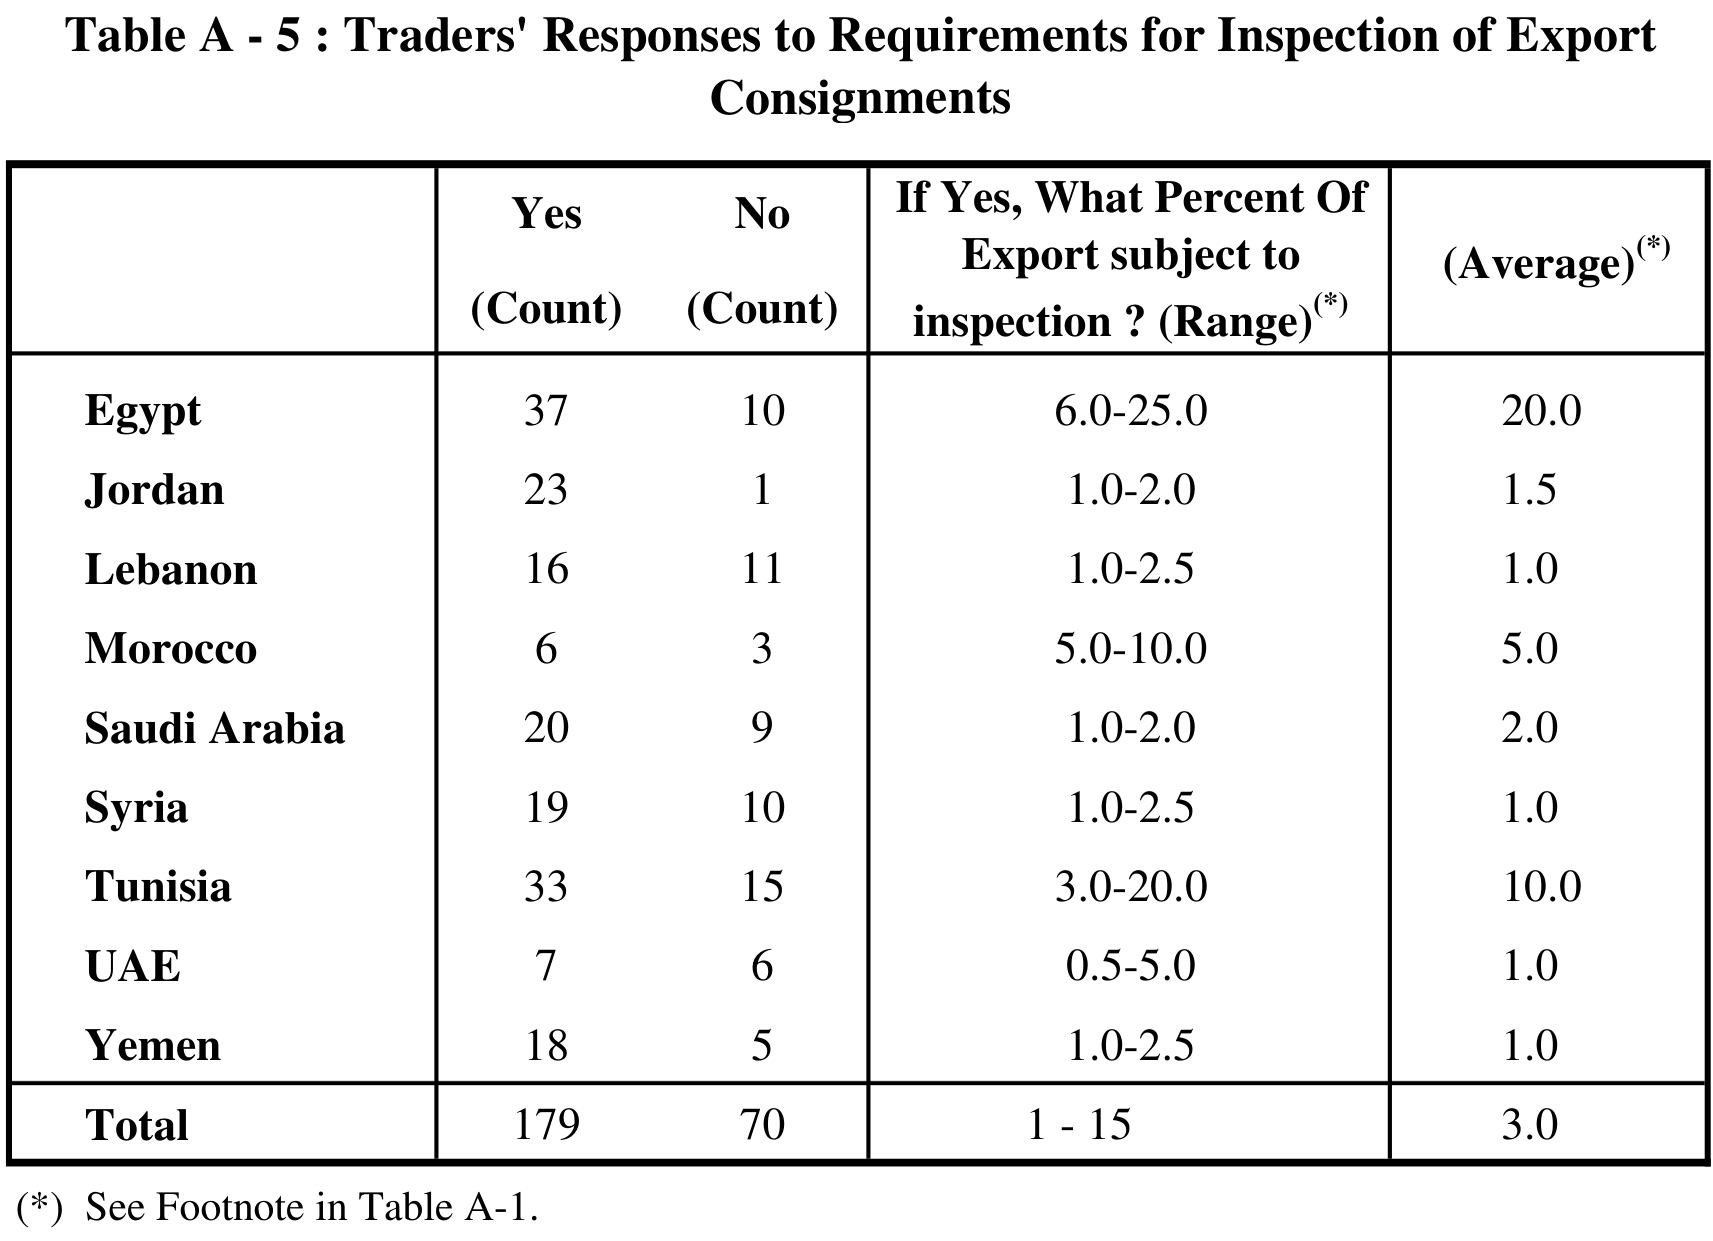

,snapshot_file_name,source,artifact_type,gap_id,gap_status,missing_metadata_concept,proposed_field_name,evidence,why_snapshot_metadata,closest_schema_paths,why_existing_fields_may_be_insufficient,material_impact,material_consequence,uncertainty_note
4,document_11017288_table_007.png,prwp,table,gap_001,possible,Explicit cross-reference to another snapshot or table containing an interpretive footnote needed for marked columns.,related_snapshot_references,The table marks the 'Range' and '(Average)' column headings with '(*)' and includes the note: '(*) See Footnote in Table A-1.',The note is displayed within this table and qualifies how marked values in this snapshot should be interpreted; it is not merely a parent-document citation or publication attribute.,"[interpretive_notes[], document_label]","`interpretive_notes[]` can preserve the statement as text, and `document_label` can record this snapshot's own label such as 'Table A-5', but v1.2 has no structured way to represent that this snapshot depends on, refers to, or should be interpreted together with a different labeled snapshot, 'Table A-1'. Representing the cross-reference only as free text may lose the relationship between the current table and the referenced table.",interpretability,"A metadata record could preserve the table title and variables but fail to make clear, in reusable structured metadata, that the meaning of the starred range and average values depends on an external footnote in another table; this may impair interpretation when the snapshot is used apart from the parent document or related table.","The actual content and importance of the Table A-1 footnote are not supplied, and `interpretive_notes[]` may be considered sufficient if textual preservation of the reference is adequate."


In [44]:
selected_snapshot = gap_snapshots.iloc[20]["snapshot_file_name"]
inspect_gap(selected_snapshot)


## Full results overview

This compact table supports spot-checking and navigation across all 202 substantive results.


In [19]:
overview_df = results_df.sort_values(
    ["coverage_assessment", "source", "artifact_type", "snapshot_file_name"]
).reset_index(drop=True)
display(overview_df)


,snapshot_file_name,source,artifact_type,schema_version,coverage_assessment,candidate_count,elapsed_seconds
0,document_11777361_figure_006.png,prwp,figure,1.2,critical_gap_found,1,10.169927
1,200_multi-page_figure_003.png,refugee,figure,1.2,critical_gap_found,2,26.867360
2,protection_trends_paper_no_7_jan-mar_2016_fina...,unhcr,figure,1.2,critical_gap_found,1,19.179053
3,document_10240515_figure_000.png,prwp,figure,1.2,no_critical_gap_found,0,8.220539
4,document_10395051_figure_006.png,prwp,figure,1.2,no_critical_gap_found,0,6.712758
...,...,...,...,...,...,...,...
197,finalreferralcarelebanon2014imcfinancial_figur...,unhcr,figure,1.2,possible_gap,1,23.151865
198,lebanonhausreport2015final_figure_010.png,unhcr,figure,1.2,possible_gap,1,15.899141
199,unhcr_global_report_2020_-_west_and_central_af...,unhcr,figure,1.2,possible_gap,1,48.854659
200,190415_gbv_secondary-data-analysis_cyclone-ida...,unhcr,table,1.2,possible_gap,1,39.326406


## Unresolved errors

A successful completed run should leave this table empty.


In [20]:
errors_df = pd.json_normalize(errors) if errors else pd.DataFrame()
display(errors_df)


""
